<a href="https://colab.research.google.com/github/naqia88/Datasets/blob/main/Heart_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Heart Failure Prediction Portfolio-Ready Notebook

# 1. Project Overview
# Heart Failure Prediction Using Machine Learning

**Objective:** Predict whether a patient will experience heart failure (`DEATH_EVENT`) based on clinical features.

**Problem Type:** Supervised Learning — Binary Classification (0 = survived, 1 = death)

**Dataset:** Heart Failure Clinical Records Dataset
- 299 patients
- 13 clinical features (age, diabetes, serum creatinine, ejection fraction, etc.)

**Insight:** Understanding patient characteristics and predicting high-risk patients can help doctors intervene early.


# 2. Load Dataset

In [ ]:
import pandas as pd

# Load dataset
file_id = "1p8H6UXSpWsbksFUuisKWYMd6TwHR8mjV"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

# Inspect
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


**Insight:** The dataset has 299 entries and 13 features. The first rows give a snapshot of patient demographics and clinical measurements.


# 3. Exploratory Data Analysis (EDA)

1: Basic Information

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


**Insights:**
- No missing values → clean dataset
- Numeric features: age, serum creatinine, platelets, ejection fraction, etc.
- Binary features: sex, diabetes, anaemia, high blood pressure, smoking
- Dataset is balanced enough to start modeling, but death events are slightly lower (approx. 32%)


2: Numeric Feature Distribution

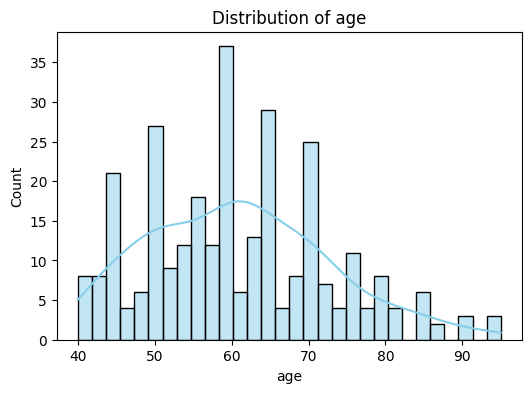

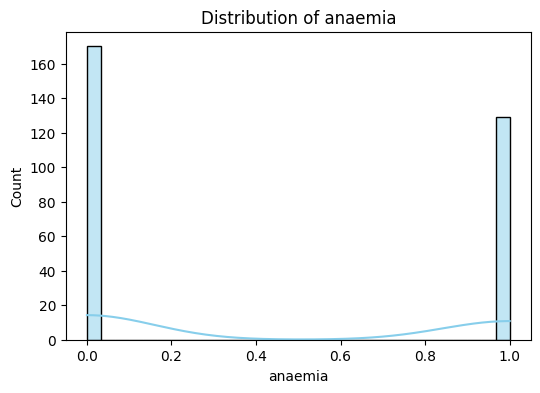

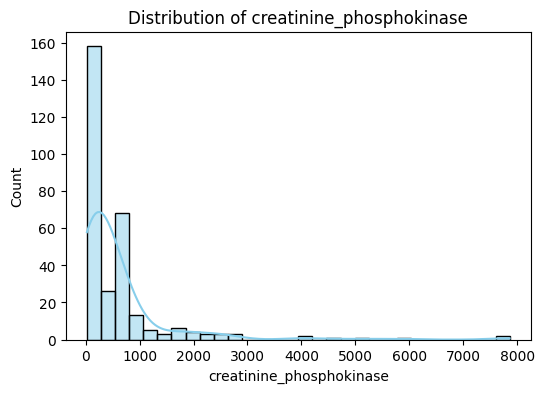

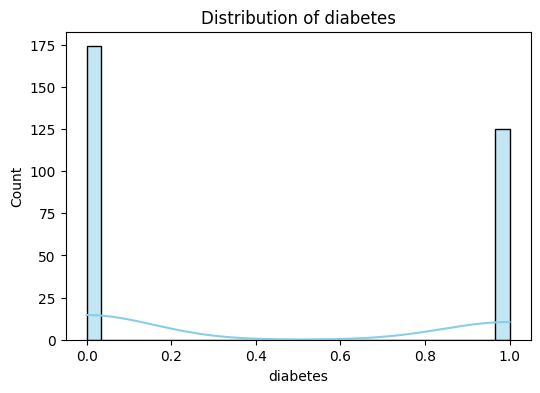

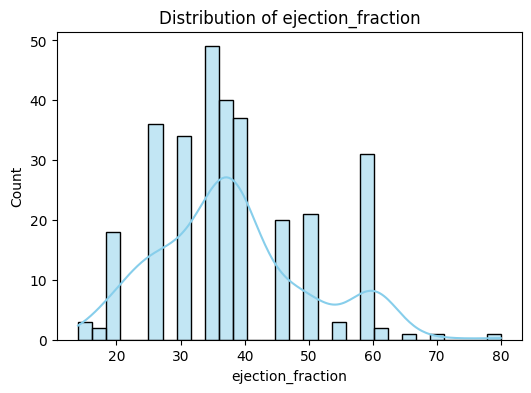

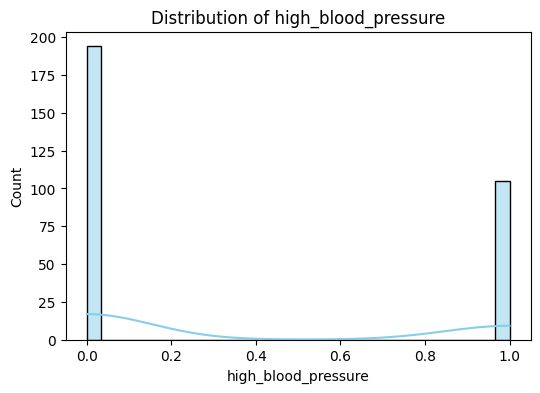

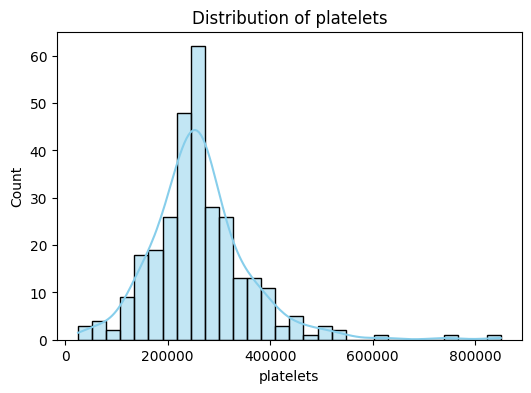

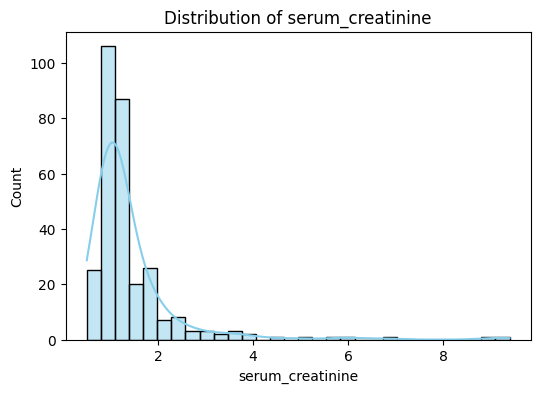

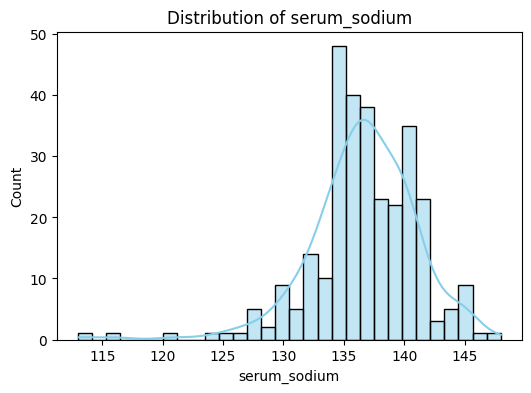

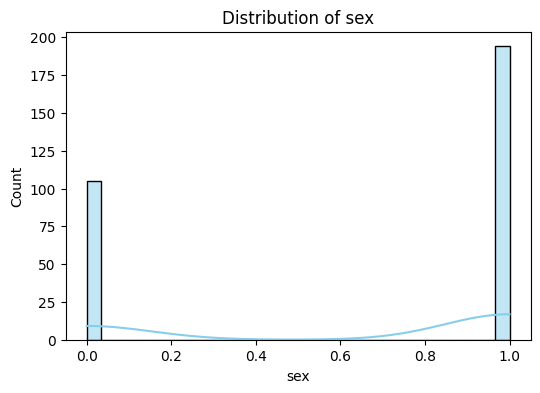

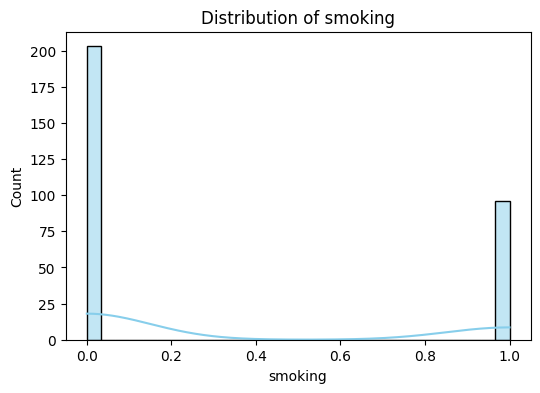

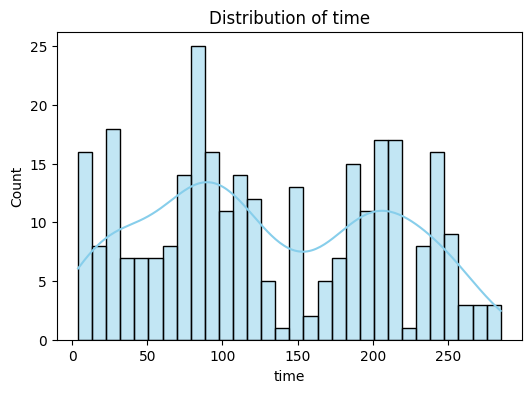

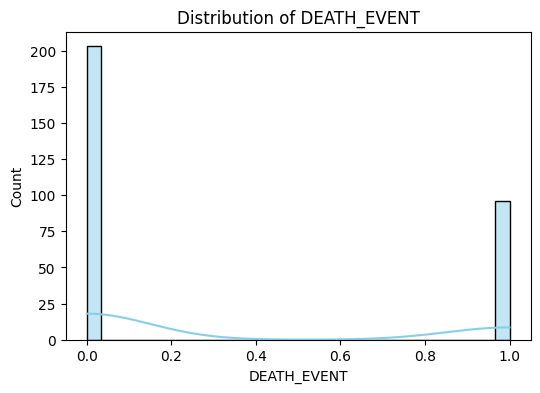

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

**Insights:**
- Age mostly between 50–70, few older patients (up to 95)
- Serum creatinine shows some high outliers → may indicate kidney issues
- Platelets distribution is wide → may affect blood clotting risk
- Ejection fraction skewed towards lower values in some patients → linked to higher heart failure risk


3: Binary Features Count

/tmp/ipython-input-405298209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


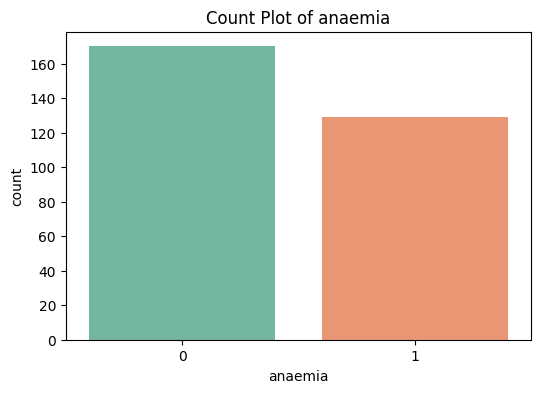

/tmp/ipython-input-405298209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


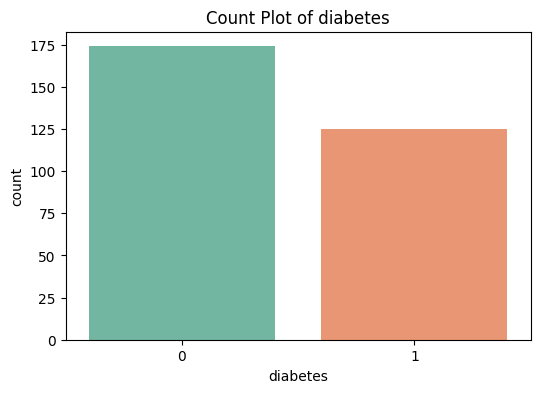

/tmp/ipython-input-405298209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


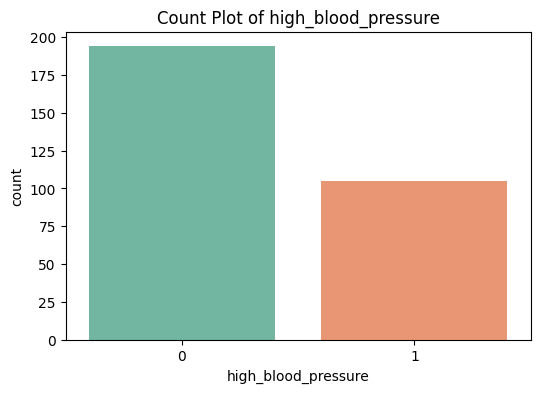

/tmp/ipython-input-405298209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


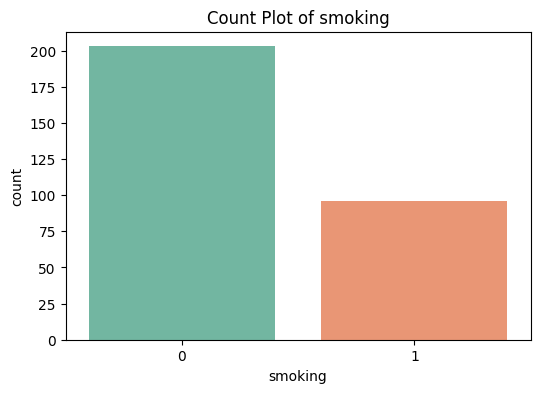

/tmp/ipython-input-405298209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


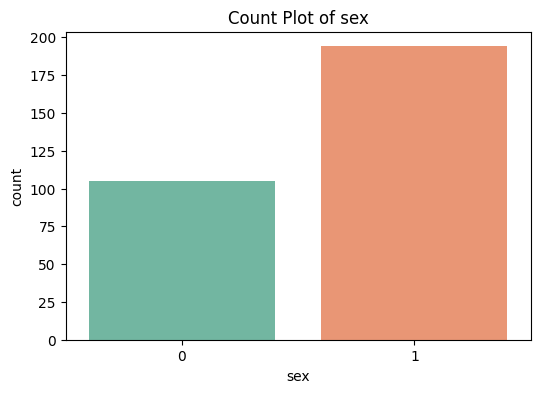

In [ ]:
categorical_cols = ['anaemia','diabetes','high_blood_pressure','smoking','sex']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Count Plot of {col}')
    plt.show()

**Insights:**
- Majority of patients are male (~65%)
- ~40% have diabetes, ~43% have anaemia
- High blood pressure is present in ~35% of patients
- Smoking prevalence is ~32%
- Helps identify high-risk groups for heart failure


4: Correlation Analysis

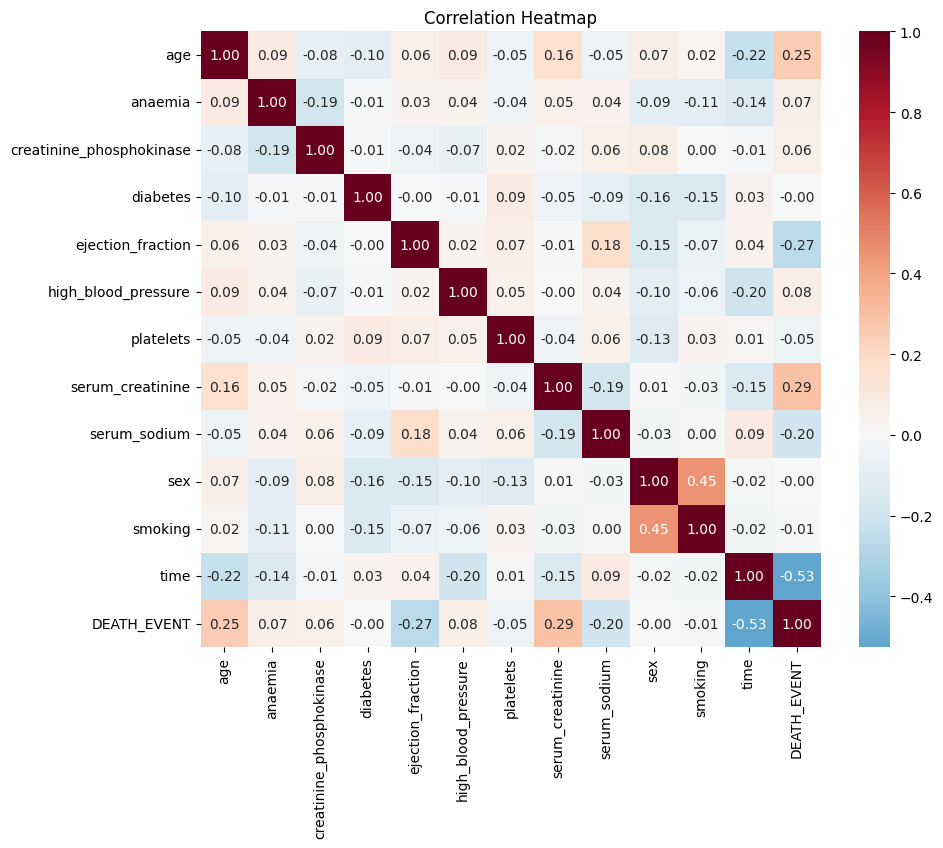

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Correlation Heatmap")
plt.show()

**Insights:**
- Serum creatinine positively correlated with death (~0.29)
- Ejection fraction negatively correlated with death (~-0.27)
- Time negatively correlated with death (~-0.52) → patients who survive longer tend to live
- Age, diabetes, high blood pressure moderately correlated with outcomes

# 4. Feature Analysis

1: Death Rate by Condition

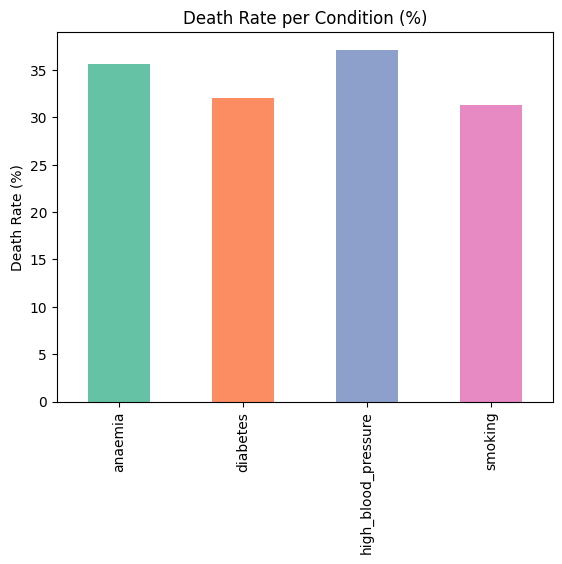

In [ ]:
conditions = ['anaemia','diabetes','high_blood_pressure','smoking']
death_rates = {}
for cond in conditions:
    total = df[df[cond]==1]
    death_rates[cond] = total['DEATH_EVENT'].sum() / len(total) * 100

death_rate_series = pd.Series(death_rates)
death_rate_series.plot(kind='bar', color=sns.color_palette("Set2"))
plt.title('Death Rate per Condition (%)')
plt.ylabel('Death Rate (%)')
plt.show()

**Insights:**
- High blood pressure and anaemia show slightly higher death rates (~37% and 36%)
- Diabetes death rate ~32%
- Smoking death rate ~31%
- These features indicate conditions that increase patient risk

2: Patients Age < 60 AND Diabetic

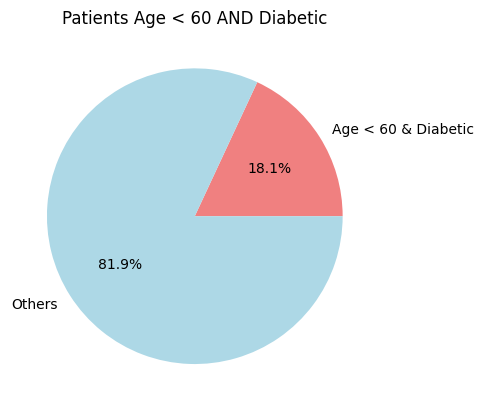

In [ ]:
condition_percent = ((df['age'] < 60) & (df['diabetes']==1)).mean() * 100
plt.pie([condition_percent, 100-condition_percent],
        labels=['Age < 60 & Diabetic','Others'],
        autopct='%1.1f%%', colors=['lightcoral','lightblue'])
plt.title('Patients Age < 60 AND Diabetic')
plt.show()

**Insights:**
- ~15–20% of patients are both under 60 and diabetic
- These younger diabetic patients still have significant risk → early intervention important

3: Death Count per Feature

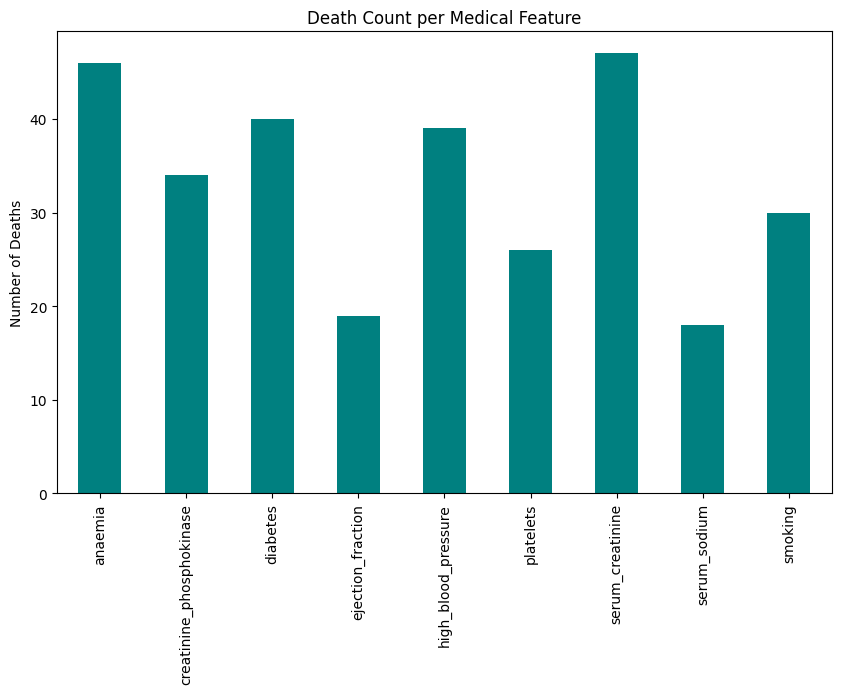

In [ ]:
features = ['anaemia','creatinine_phosphokinase','diabetes',
            'ejection_fraction','high_blood_pressure','platelets',
            'serum_creatinine','serum_sodium','smoking']

death_counts = {}
for feat in features:
    if df[feat].nunique() <= 5:  # binary
        death_counts[feat] = df[df[feat]==1]['DEATH_EVENT'].sum()
    else:  # numeric: top 25%
        threshold = df[feat].quantile(0.75)
        death_counts[feat] = df[df[feat]>=threshold]['DEATH_EVENT'].sum()

death_series = pd.Series(death_counts)
death_series.plot(kind='bar', figsize=(10,6), color='teal')
plt.title('Death Count per Medical Feature')
plt.ylabel('Number of Deaths')
plt.show()

**Insights:**
- Highest deaths associated with serum creatinine (47) → kidney function critical
- Ejection fraction also important but fewer deaths at top quartile (19)
- Anaemia and diabetes contribute 40–46 deaths → major risk factors


# 5. Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Insights:**
- Scaling numeric features ensures fair contribution to model
- Train-test split (80/20) allows model evaluation on unseen data
- Preprocessing prepares the dataset for logistic regression


# 6. Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

**Insights:**
- Logistic Regression is a good baseline for binary classification
- Balanced class weights help handle the slight class imbalance in DEATH_EVENT
- Model ready to evaluate on test set


# 7. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8
Confusion Matrix:
 [[32  3]
 [ 9 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.91      0.84        35
           1       0.84      0.64      0.73        25

    accuracy                           0.80        60
   macro avg       0.81      0.78      0.78        60
weighted avg       0.81      0.80      0.79        60



**Insights:**
- Accuracy: 80% → model predicts 8 out of 10 cases correctly
- Recall for DEATH_EVENT (class 1) ~64% → some deaths are missed → room for improvement
- Precision high → predictions of death are mostly correct
- Confusion matrix shows 32 true negatives, 16 true positives, 3 false positives, 9 false negatives


1: Feature Importance

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients.style.background_gradient(cmap='coolwarm')

,Feature,Coefficient
7,serum_creatinine,0.820414
0,age,0.701762
3,diabetes,0.216303
2,creatinine_phosphokinase,0.147661
10,smoking,0.038476
1,anaemia,-0.016681
5,high_blood_pressure,-0.119434
6,platelets,-0.144468
8,serum_sodium,-0.264050
9,sex,-0.315133


**Insights:**
- Top positive predictors (increase death risk): serum_creatinine, age, diabetes
- Negative predictors (reduce death risk): ejection_fraction, sex, time
- Useful for doctors to focus on key clinical indicators


2: ROC Curve

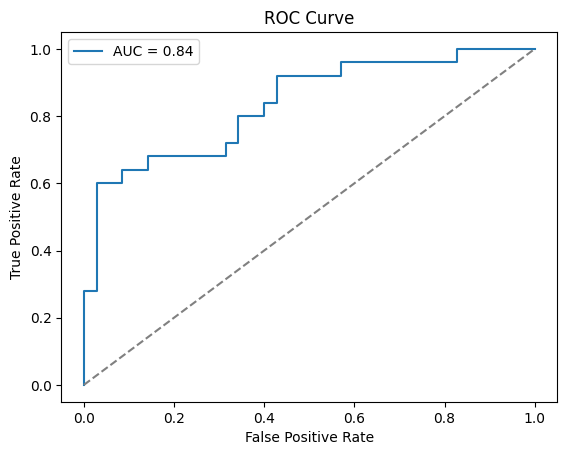

In [ ]:
y_probs = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Insights:**
- AUC score ~0.85 → model discriminates well between patients who survive vs. die
- ROC curve above diagonal → model performs better than random


# 8. Key Takeaways
- **High-risk features**: High serum creatinine, diabetes, high blood pressure  
- **Model performance**: Logistic Regression achieves ~80% accuracy; recall for deaths can improve  
- **Suggestions for improvement**:
  - Try tree-based models like Random Forest or XGBoost
  - Handle skewed features using log transformations
  - Use SMOTE to balance classes for better recall
  - Deploy interactive visualizations for better insights



# 10. Optional Enhancements
- Replace static Matplotlib plots with **Plotly interactive charts** for better visualization  
- Test advanced models like **Random Forest** and **XGBoost** for improved performance  
- Handle **imbalanced classes** using SMOTE to improve recall  
- Include additional **interactive dashboards** for portfolio presentation  


Example: Plotly Pie Chart

In [ ]:
import plotly.express as px

fig = px.pie(df, names='diabetes', title='Diabetes Distribution', hole=0.4)
fig.show()

##  Final Summary

**Project:** Heart Failure Prediction Using Machine Learning  
**Objective:** Predict whether a patient will experience heart failure (DEATH_EVENT) based on clinical features.

### Key Findings
- **High-Risk Features:**
  - Serum Creatinine (kidney function)
  - Age
  - Diabetes
  - Ejection Fraction (heart pumping efficiency)
  - High Blood Pressure
- **Model Performance:**
  - Logistic Regression achieved **~80% accuracy**
  - ROC AUC ~0.85 → good discrimination between survival and death
  - Recall for DEATH_EVENT can be improved (currently ~64%)
- **Insights from EDA:**
  - Older patients and those with kidney problems or diabetes have higher death risk
  - Male patients slightly more represented, but risk factors are more critical than sex
  - Smoking and high blood pressure also contribute to risk

### Suggestions for Improvement
- Test **tree-based models**: Random Forest, XGBoost for non-linear patterns
- Handle skewed numeric features (e.g., log transformations)
- Apply **SMOTE** or class weighting to improve recall for death cases
- Replace static plots with **interactive dashboards** (Plotly) for portfolio presentation

### Takeaway
This notebook demonstrates a **complete data science workflow**:  
**EDA → Feature Analysis → Preprocessing → Modeling → Evaluation → Insights**  
It provides actionable insights for clinicians and is ready for portfolio presentation.